## Linear Regression (Marketing ROI Analysis)

This project analuzes the relationship between advertising spending sales using Simple Linear Regression

## [CODE CELL]

In [18]:
# Import Libraries.
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm 

# Load the dataset.
df = pd.read_csv("Marketing_and_Sales_Data_Evaluate.csv")

# Display the first few rows of the dataset.
print(df.head())

     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181


In [19]:
# Explore the dataset.

print(df.info())   # Check for data types and missing values.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None


In [20]:
print(df.describe())   # Get summary statistics for numerical columns.


                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.000000    17.859513      3.055565   189.231172
75%      77.000000    25.649730      4.807558   272.507922
max     100.000000    48.871161     13.981662   364.079751


In [21]:

print(df.isnull().sum())   # Check for missing values in each column.

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64


In [22]:
# Handle missing values if necessary (e.g., imputation or dropping rows/columns).
df = df.dropna()  # Example: Drop rows with missing values.

## [EXPLORATORY DATA ANALYSIS]

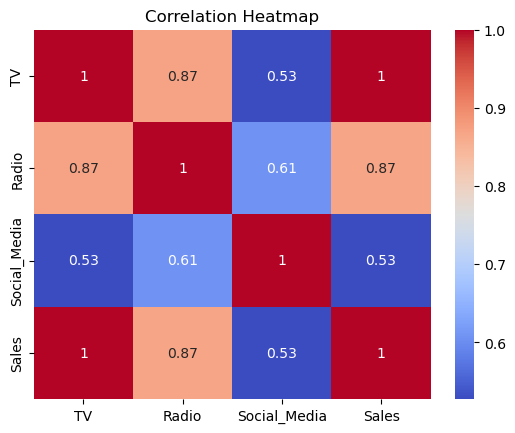

In [23]:
#1. Correlation Heatmap.
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

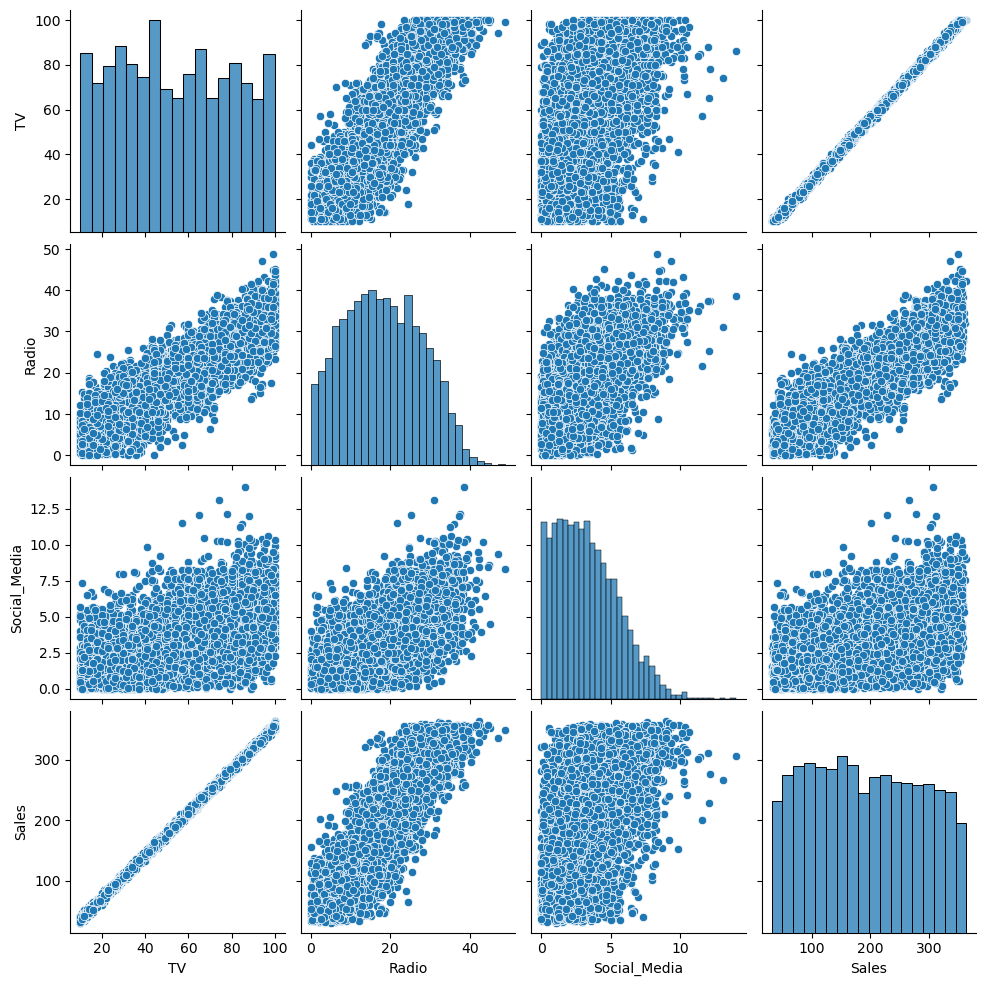

In [24]:
#2.  Pairplot to visualize relationships between variables.
sns.pairplot(df)
plt.show

## BEST PREDICTOR

In [25]:
# find the best predictor variable for sales
correlation_matrix = df.corr()
sales_correlation = correlation_matrix['Sales'].drop('Sales')  # Exclude the target variable itself
sales_correlation = sales_correlation.sort_values(ascending=False)
print(sales_correlation)

TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


### SIMPLE LINEAR REGRESSION MODEL

In [26]:
# Simple Linear Regression using the best predictor variable ('TV').
X = df['TV']  # Independent variable (best predictor)
y = df['Sales']  # Dependent variable

#Add a constant to the independent variable for the intercept term.
X = sm.add_constant(X)

# Fit the OLS regression model.
model = sm.OLS(y, X).fit()

# Print the model summary.
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Wed, 10 Jun 2026   Prob (F-statistic):               0.00
Time:                        04:04:00   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## REGRESSION LINE VISUALIZATION

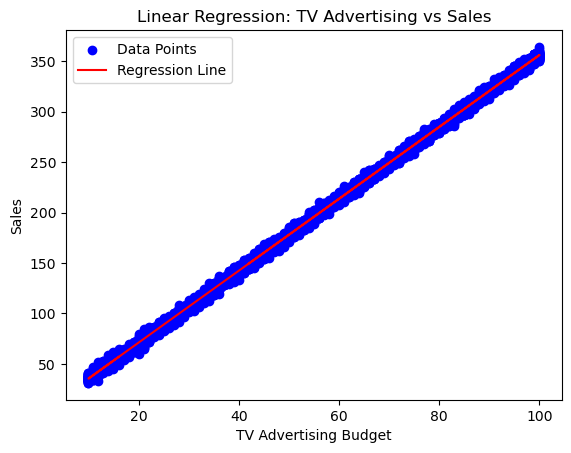

In [27]:
# Regression Line Visualization.
plt.scatter(df['TV'], df['Sales'], color='blue', label='Data Points')
plt.plot(df['TV'], model.predict(X), color='red', label='Regression Line')
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')
plt.title('Linear Regression: TV Advertising vs Sales')
plt.legend()
plt.show()

 ## [DIAGNOSTIC PLOTS]

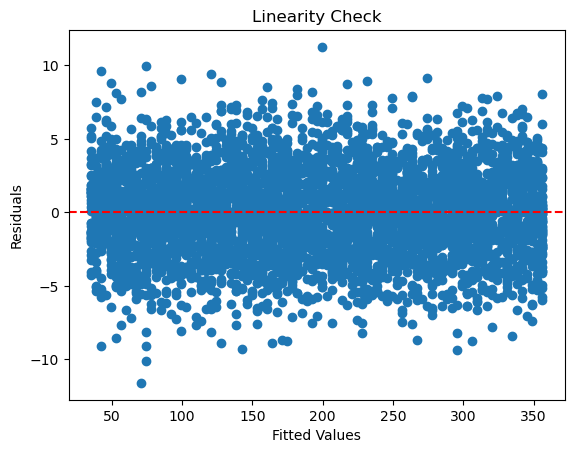

In [28]:
# Verify key regression assumptions through diagnostic plots.

# Residuals vs Fitted Values Plot.
residuals = model.resid
fitted = model.fittedvalues

#Linearity Check.
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Linearity Check')
plt.show()

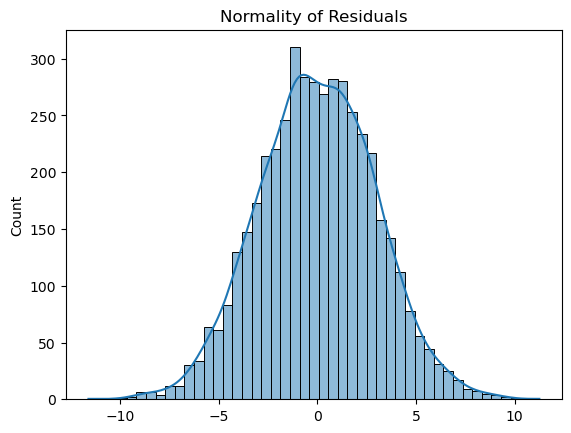

In [29]:
# Normality of Residuals Check.
sns.histplot(residuals, kde=True)
plt.title('Normality of Residuals')
plt.show()

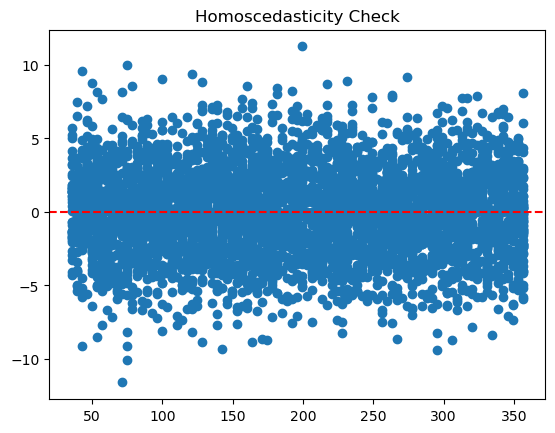

In [30]:
# Homoscedasticity Check.
plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Homoscedasticity Check')
plt.show()

## BUSINESS INTERPRETATION

In [31]:
# Business Interpretation of Results.
print(f"Coefficient for TV Advertising: {model.params['TV']}")
print(f"P-Values: {model.pvalues}")
print(f"R-squared: {model.rsquared}")

Coefficient for TV Advertising: 3.5615140946411636
P-Values: const    0.187919
TV       0.000000
dtype: float64
R-squared: 0.998994984518024


## BUSINESS RECOMMENDATION

In [32]:
# ROI Recommendation.
if model.params['TV'] > 0 and model.pvalues['TV'] < 0.05:
    print("Recommendation: Increase TV advertising budget because it has a significant positive impact on sales and high ROI.")

Recommendation: Increase TV advertising budget because it has a significant positive impact on sales and high ROI.
